# MTRN3100 Task 4.1.1 - BFS Maze Path Generation

This notebook converts an overhead image of the **9 x 9** Micromouse maze into a graph, solves it with BFS, and produces the `l`, `f`, `r` string used by the Arduino movement code.

The demonstrator can see all three required stages:

1. the original image and calibrated maze area;
2. the rectified grid with detected open and blocked connections;
3. the BFS path and generated command string.


## 1. Imports and calibration

`MAZE_CORNERS` contains the four pixel coordinates of the 9 x 9 grid in the order **top-left, top-right, bottom-right, bottom-left**. Each point is written as **`(x, y)`**: `x` increases to the right and `y` increases downward from the image's top-left. The supplied values are calibrated for the current 1440 x 960 photograph. Calibrate these once before marking and keep the overhead camera fixed; they describe the camera geometry, not the maze solution.

| Array row | Corner controlled | First number | Second number |
|---|---|---|---|
| `0` | Top-left | x | y |
| `1` | Top-right | x | y |
| `2` | Bottom-right | x | y |
| `3` | Bottom-left | x | y |

Increasing `x` moves only that corner right; decreasing it moves the corner left. Increasing `y` moves it down; decreasing it moves it up. The calibration preview below shows both the selected quadrilateral and the resulting perspective-corrected grid.

`WALL_SCORE_THRESHOLD` separates an open boundary from a wall. Use the red crosses and green connections in the final visualisation to validate it before marking day.


In [1]:
import argparse
from collections import deque

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# ---------------- SYSTEM PARAMETERS ----------------

GRID_SIZE = 9
RECTIFIED_SIZE = 900

# Image coordinates are (x, y): x increases right and y increases down.
# Corner order: top-left, top-right, bottom-right, bottom-left.
# Recalibrate these once if the overhead camera moves.
MAZE_CORNERS = np.float32([
    [394, 138],   # 0: top-left
    [1066, 153],  # 1: top-right
    [1037, 811],  # 2: bottom-right
    [392, 792],   # 3: bottom-left
])

# Each wall is checked near the middle of its cell boundary. The detector looks
# for one dark line that stays roughly parallel to the expected boundary. This
# finds thin raised walls without joining unrelated shadows across a wide band.
BOUNDARY_END_MARGIN = 0.17
BOUNDARY_PADDING = 0.35
WALL_SEARCH_RADIUS = 0.15
WALL_LINE_RADIUS = 0.03
WALL_MAX_SLOPE = 0.25
WALL_SLOPE_STEPS = 21
WALL_SCORE_THRESHOLD = 0.90
WALL_UNCERTAIN_MARGIN = 0.05
WALL_PROFILE_GAP_SIZE = 7
WALL_MASK_THRESHOLD_SCALE = 1.43


## 2. Graph representation


In [2]:
# ---------------- GRAPH CLASS ----------------

class Node:
    def __init__(self, node_id, row, column, x, y):
        self.id = node_id
        self.row = row
        self.column = column
        self.x = x
        self.y = y

    def get_point(self):
        return (self.x, self.y)

    def get_cell(self):
        return (self.row, self.column)


class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, row, column, x, y):
        if node_id in self.nodes:
            print("Error: Node has already been added to the graph")
            return

        self.nodes[node_id] = Node(node_id, row, column, x, y)
        self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight=1):
        if node_id1 not in self.nodes or node_id2 not in self.nodes:
            print("Error: One or both nodes do not exist in the graph")
            return

        self.edges[node_id1][node_id2] = weight
        self.edges[node_id2][node_id1] = weight


## 3. Convert the photograph into a 9 x 9 graph

The image is perspective-corrected to 900 x 900 pixels, so each maze cell is exactly 100 x 100 pixels. For every neighbouring pair of cells, the code examines only the middle of their shared boundary. This avoids counting the blue wall clips and black intersection markers.

The detector searches for a **continuous dark line that remains roughly parallel to the expected cell boundary**. This detects a thin raised wall even when parallax shifts it a few pixels away from the cyan grid line. A floor seam, shadow, wall clip, cylinder or diagonal outer frame does not remain on one candidate line for the full cell length, so it is rejected. Orange circles in the final plot identify scores close to the decision threshold and therefore worth checking.


In [3]:
# ---------------- IMAGE PROCESSING ----------------

def rectify_maze(image, maze_corners, output_size=RECTIFIED_SIZE):
    destination = np.float32([
        [0, 0],
        [output_size - 1, 0],
        [output_size - 1, output_size - 1],
        [0, output_size - 1],
    ])

    transform = cv2.getPerspectiveTransform(maze_corners, destination)
    rectified = cv2.warpPerspective(image, transform, (output_size, output_size))

    return rectified


def create_wall_mask(rectified_image):
    gray = cv2.cvtColor(rectified_image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    otsu_threshold, _ = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    dark_threshold = min(
        255,
        int(round(otsu_threshold * WALL_MASK_THRESHOLD_SCALE)),
    )

    _, wall_mask = cv2.threshold(
        gray,
        dark_threshold,
        255,
        cv2.THRESH_BINARY_INV,
    )

    return wall_mask


def boundary_wall_score(wall_mask, row1, column1, row2, column2):
    cell_size = wall_mask.shape[0] // GRID_SIZE
    end_margin = int(round(cell_size * BOUNDARY_END_MARGIN))
    padding = int(round(cell_size * BOUNDARY_PADDING))
    search_radius = int(round(cell_size * WALL_SEARCH_RADIUS))
    line_radius = max(1, int(round(cell_size * WALL_LINE_RADIUS)))

    if row1 == row2:
        # Left/right neighbours share a vertical boundary.
        boundary_x = max(column1, column2) * cell_size
        start_y = row1 * cell_size + end_margin
        end_y = (row1 + 1) * cell_size - end_margin
        region = wall_mask[
            start_y:end_y,
            boundary_x - padding:boundary_x + padding + 1,
        ]
    else:
        # Up/down neighbours share a horizontal boundary.
        boundary_y = max(row1, row2) * cell_size
        start_x = column1 * cell_size + end_margin
        end_x = (column1 + 1) * cell_size - end_margin
        region = wall_mask[
            boundary_y - padding:boundary_y + padding + 1,
            start_x:end_x,
        ].T

    if region.size == 0:
        return 1.0

    # region is always arranged as (distance along boundary, distance across
    # boundary). Search several nearly parallel lines near the expected grid
    # edge. A real wall gives high coverage on one line; a diagonal frame,
    # shadow, cylinder or wall clip does not stay on that line for the full
    # cell length.
    dark_region = region > 0
    length, width = dark_region.shape
    along_positions = np.arange(length, dtype=np.float32)[:, None]
    first_offset = max(line_radius, padding - search_radius)
    last_offset = min(width - line_radius, padding + search_radius + 1)
    candidate_offsets = np.arange(
        first_offset,
        last_offset,
        dtype=np.float32,
    )[None, :]

    if candidate_offsets.size == 0:
        return 1.0

    row_indices = np.arange(length)[:, None]
    best_score = 0.0
    gap_kernel = np.ones((WALL_PROFILE_GAP_SIZE, 1), np.uint8)

    for slope in np.linspace(-WALL_MAX_SLOPE, WALL_MAX_SLOPE, WALL_SLOPE_STEPS):
        line_positions = np.rint(
            candidate_offsets
            + slope * (along_positions - (length - 1) / 2)
        ).astype(np.int32)
        valid = (
            (line_positions >= line_radius)
            & (line_positions < width - line_radius)
        )
        wall_profiles = np.zeros(line_positions.shape, dtype=np.uint8)

        for offset in range(-line_radius, line_radius + 1):
            sample_positions = np.clip(line_positions + offset, 0, width - 1)
            wall_profiles |= (
                dark_region[row_indices, sample_positions] & valid
            ).astype(np.uint8)

        # Fill only short gaps along each candidate line. This handles glare
        # and compression but cannot combine separate objects across the band.
        wall_profiles = cv2.morphologyEx(
            wall_profiles,
            cv2.MORPH_CLOSE,
            gap_kernel,
        )
        slope_score = float(np.max(np.mean(wall_profiles > 0, axis=0)))
        best_score = max(best_score, slope_score)

    return best_score


def generate_maze_graph(wall_mask):
    graph = Graph()
    boundary_scores = {}
    cell_size = wall_mask.shape[0] // GRID_SIZE

    for row in range(GRID_SIZE):
        for column in range(GRID_SIZE):
            node_id = row * GRID_SIZE + column
            x = column * cell_size + cell_size // 2
            y = row * cell_size + cell_size // 2
            graph.add_node(node_id, row, column, x, y)

    for row in range(GRID_SIZE):
        for column in range(GRID_SIZE):
            node_id = row * GRID_SIZE + column

            if column < GRID_SIZE - 1:
                right_id = row * GRID_SIZE + column + 1
                score = boundary_wall_score(
                    wall_mask,
                    row,
                    column,
                    row,
                    column + 1,
                )
                boundary_scores[(node_id, right_id)] = score

                if score < WALL_SCORE_THRESHOLD:
                    graph.add_edge(node_id, right_id)

            if row < GRID_SIZE - 1:
                below_id = (row + 1) * GRID_SIZE + column
                score = boundary_wall_score(
                    wall_mask,
                    row,
                    column,
                    row + 1,
                    column,
                )
                boundary_scores[(node_id, below_id)] = score

                if score < WALL_SCORE_THRESHOLD:
                    graph.add_edge(node_id, below_id)

    return graph, boundary_scores


## 4. BFS and command generation

BFS uses a `parent` list to reconstruct the shortest cell path. The second function compares consecutive cells with the robot's current heading and inserts the required `l` or `r` before each `f`. A 180-degree reversal becomes `rrf`.


In [4]:
# ---------------- BFS AND COMMAND GENERATION ----------------

def bfs(graph, start_node_id, end_node_id):
    visited = [False] * len(graph.nodes)
    parent = [None] * len(graph.nodes)
    queue = deque([start_node_id])
    visited[start_node_id] = True

    while queue:
        current = queue.popleft()

        if current == end_node_id:
            path = []

            while current is not None:
                path.append(current)
                current = parent[current]

            return path[::-1]

        for neighbour in graph.edges[current]:
            if not visited[neighbour]:
                visited[neighbour] = True
                parent[neighbour] = current
                queue.append(neighbour)

    return []


def path_to_commands(graph, path, start_direction):
    directions = ["N", "E", "S", "W"]
    movement_direction = {
        (-1, 0): "N",
        (0, 1): "E",
        (1, 0): "S",
        (0, -1): "W",
    }

    current_direction = start_direction.upper()
    commands = []

    for i in range(len(path) - 1):
        current_cell = graph.nodes[path[i]].get_cell()
        next_cell = graph.nodes[path[i + 1]].get_cell()
        row_change = next_cell[0] - current_cell[0]
        column_change = next_cell[1] - current_cell[1]
        required_direction = movement_direction[(row_change, column_change)]

        current_index = directions.index(current_direction)
        required_index = directions.index(required_direction)
        turn = (required_index - current_index) % 4

        if turn == 1:
            commands.append("r")
        elif turn == 2:
            commands.extend(["r", "r"])
        elif turn == 3:
            commands.append("l")

        commands.append("f")
        current_direction = required_direction

    return "".join(commands)


## 5. Visual verification

`show_maze_corner_calibration()` labels all four input corners and shows the resulting rectified grid beside them. Edit `MAZE_CORNERS`, rerun the parameter cell, and rerun the final cell until the cyan grid lines align with the physical maze cells.


In [5]:
# ---------------- VISUALISATION ----------------

def draw_maze_corners(image, maze_corners):
    result = image.copy()
    corners = maze_corners.astype(np.int32)
    corner_names = ["TOP-LEFT", "TOP-RIGHT", "BOTTOM-RIGHT", "BOTTOM-LEFT"]
    corner_colours = [
        (0, 255, 255),
        (255, 0, 255),
        (255, 255, 0),
        (0, 165, 255),
    ]
    label_offsets = [
        (18, -18),
        (-330, -18),
        (-370, 42),
        (18, 42),
    ]

    cv2.polylines(result, [corners], True, (0, 255, 255), 5)

    for i, (x, y) in enumerate(corners):
        colour = corner_colours[i]
        label_x = x + label_offsets[i][0]
        label_y = y + label_offsets[i][1]
        label = f"{i}: {corner_names[i]} ({x}, {y})"

        cv2.circle(result, (x, y), 14, colour, -1)
        cv2.circle(result, (x, y), 18, (0, 0, 0), 3)
        cv2.putText(
            result,
            label,
            (label_x, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 0),
            5,
        )
        cv2.putText(
            result,
            label,
            (label_x, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            colour,
            2,
        )

    # Coordinate guide: image coordinates start at the top-left.
    axis_origin = (55, 55)
    cv2.arrowedLine(result, axis_origin, (280, 55), (0, 0, 255), 5, tipLength=0.08)
    cv2.arrowedLine(result, axis_origin, (55, 280), (255, 0, 0), 5, tipLength=0.08)
    cv2.putText(result, "+x", (290, 65), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
    cv2.putText(result, "+y", (65, 300), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 3)
    cv2.putText(
        result,
        "(0, 0) is the image's top-left",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (0, 0, 0),
        4,
    )
    cv2.putText(
        result,
        "(0, 0) is the image's top-left",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2,
    )

    return result


def show_maze_corner_calibration(image_file, maze_corners=None):
    if maze_corners is None:
        maze_corners = MAZE_CORNERS

    image = cv2.imread(image_file)

    if image is None:
        raise FileNotFoundError(f"Could not open image: {image_file}")

    corner_names = ["top-left", "top-right", "bottom-right", "bottom-left"]
    corner_image = draw_maze_corners(image, maze_corners)
    rectified_preview = rectify_maze(image, maze_corners)
    cell_size = rectified_preview.shape[0] // GRID_SIZE

    for i in range(GRID_SIZE + 1):
        location = min(i * cell_size, rectified_preview.shape[0] - 1)
        cv2.line(
            rectified_preview,
            (location, 0),
            (location, rectified_preview.shape[0] - 1),
            (200, 200, 0),
            2,
        )
        cv2.line(
            rectified_preview,
            (0, location),
            (rectified_preview.shape[1] - 1, location),
            (200, 200, 0),
            2,
        )

    print("MAZE_CORNERS uses original-image pixel coordinates in (x, y) order:")
    for i, (x, y) in enumerate(maze_corners.astype(int)):
        print(f"  {i}: {corner_names[i]:<12} = ({x}, {y})")
    print("Increase x -> move that corner right; decrease x -> move it left.")
    print("Increase y -> move that corner down;  decrease y -> move it up.")

    figure, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Edit these four (x, y) points on the original image")
    axes[1].imshow(cv2.cvtColor(rectified_preview, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Resulting warp: grid lines should align with maze cells")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def draw_maze_graph(rectified_image, graph, boundary_scores, path, start_id, goal_id):
    result = rectified_image.copy()
    cell_size = rectified_image.shape[0] // GRID_SIZE

    for i in range(GRID_SIZE + 1):
        location = min(i * cell_size, rectified_image.shape[0] - 1)
        cv2.line(result, (location, 0), (location, result.shape[0] - 1), (200, 200, 0), 1)
        cv2.line(result, (0, location), (result.shape[1] - 1, location), (200, 200, 0), 1)

    for (node_id1, node_id2), score in boundary_scores.items():
        point1 = graph.nodes[node_id1].get_point()
        point2 = graph.nodes[node_id2].get_point()
        middle_x = (point1[0] + point2[0]) // 2
        middle_y = (point1[1] + point2[1]) // 2

        if score < WALL_SCORE_THRESHOLD:
            cv2.line(result, point1, point2, (0, 190, 0), 2)
        else:
            cv2.drawMarker(
                result,
                (middle_x, middle_y),
                (0, 0, 255),
                cv2.MARKER_TILTED_CROSS,
                16,
                2,
            )

        if abs(score - WALL_SCORE_THRESHOLD) <= WALL_UNCERTAIN_MARGIN:
            cv2.circle(result, (middle_x, middle_y), 12, (0, 165, 255), 2)

    for node in graph.nodes.values():
        cv2.circle(result, node.get_point(), 3, (0, 170, 0), -1)

    for i in range(len(path) - 1):
        point1 = graph.nodes[path[i]].get_point()
        point2 = graph.nodes[path[i + 1]].get_point()
        cv2.line(result, point1, point2, (255, 0, 0), 8)

    cv2.circle(result, graph.nodes[start_id].get_point(), 14, (0, 255, 255), -1)
    cv2.circle(result, graph.nodes[goal_id].get_point(), 14, (255, 0, 255), -1)

    return result


def display_results(original, rectified, graph_image, maze_corners):
    original_with_corners = draw_maze_corners(original, maze_corners)

    figure, axes = plt.subplots(1, 3, figsize=(19, 7))
    axes[0].imshow(cv2.cvtColor(original_with_corners, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Input image and calibrated maze area")
    axes[1].imshow(cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB))
    axes[1].set_title("2. Perspective-corrected 9 x 9 maze")
    axes[2].imshow(cv2.cvtColor(graph_image, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Detected graph and BFS solution")

    legend = [
        Line2D([0], [0], color="green", lw=2, label="Open connection"),
        Line2D([0], [0], marker="x", color="red", lw=0, label="Detected wall"),
        Line2D([0], [0], color="blue", lw=5, label="BFS path"),
        Line2D([0], [0], marker="o", color="gold", lw=0, label="Start"),
        Line2D([0], [0], marker="o", color="magenta", lw=0, label="Goal"),
        Line2D(
            [0],
            [0],
            marker="o",
            markerfacecolor="none",
            color="orange",
            lw=0,
            label="Check low-confidence boundary",
        ),
    ]
    axes[2].legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3)

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


## 6. Complete solver


In [6]:
# ---------------- MAIN PROGRAM ----------------

def report_low_confidence_boundaries(graph, boundary_scores):
    low_confidence = []

    for (node_id1, node_id2), score in boundary_scores.items():
        distance_from_threshold = abs(score - WALL_SCORE_THRESHOLD)

        if distance_from_threshold <= WALL_UNCERTAIN_MARGIN:
            cell1 = graph.nodes[node_id1].get_cell()
            cell2 = graph.nodes[node_id2].get_cell()
            low_confidence.append((distance_from_threshold, cell1, cell2, score))

    low_confidence.sort()

    # if not low_confidence:
    #     print("Wall detection check: no low-confidence internal boundaries.")
    #     return

    # print("Wall detection check: inspect the orange-circled boundaries:")

    # for _, cell1, cell2, score in low_confidence:
    #     detected_as = "wall" if score >= WALL_SCORE_THRESHOLD else "open"
    #     print(f"  {cell1} <-> {cell2}: coverage={score:.2f}, detected as {detected_as}")


def solve_maze(image_file, start, goal, maze_corners=None, show=True):
    if maze_corners is None:
        maze_corners = MAZE_CORNERS

    image = cv2.imread(image_file)

    if image is None:
        raise FileNotFoundError(f"Could not open image: {image_file}")

    start_row, start_column, start_direction = start
    goal_row, goal_column = goal

    if start_direction.upper() not in ["N", "E", "S", "W"]:
        raise ValueError("Start direction must be N, E, S or W")

    for row, column in [(start_row, start_column), (goal_row, goal_column)]:
        if not (0 <= row < GRID_SIZE and 0 <= column < GRID_SIZE):
            raise ValueError("Start and goal cells must be between 0 and 8")

    rectified = rectify_maze(image, maze_corners)
    wall_mask = create_wall_mask(rectified)
    graph, boundary_scores = generate_maze_graph(wall_mask)
    report_low_confidence_boundaries(graph, boundary_scores)

    start_id = start_row * GRID_SIZE + start_column
    goal_id = goal_row * GRID_SIZE + goal_column
    path = bfs(graph, start_id, goal_id)

    if not path:
        graph_image = draw_maze_graph(
            rectified,
            graph,
            boundary_scores,
            [],
            start_id,
            goal_id,
        )

        if show:
            display_results(image, rectified, graph_image, maze_corners)

        raise RuntimeError(
            "No path was found. Check the calibrated corners and the red/green "
            "boundary detections before changing WALL_SCORE_THRESHOLD."
        )

    cell_path = [graph.nodes[node_id].get_cell() for node_id in path]
    commands = path_to_commands(graph, path, start_direction)
    graph_image = draw_maze_graph(
        rectified,
        graph,
        boundary_scores,
        path,
        start_id,
        goal_id,
    )

    print(f"Start: {start}")
    print(f"Goal: {goal}")
    print(f"Cell path: {cell_path}")
    print(f'Command string: "{commands}"')
    print(f'Paste into Arduino: const char commandString[] = "{commands}";')

    if show:
        display_results(image, rectified, graph_image, maze_corners)

    return cell_path, commands, graph_image


## 7. Run on the supplied image

Replace only `START` and `GOAL` when the demonstrator gives them to you. `START` is `(row, column, direction)` and `GOAL` is `(row, column)`.

The example below begins in a connected cell in the supplied Task 4.2-style photograph so that the complete pipeline can be displayed. For the actual 4.1.1 maze, enter the provided coordinates.


MAZE_CORNERS uses original-image pixel coordinates in (x, y) order:
  0: top-left     = (394, 138)
  1: top-right    = (1066, 153)
  2: bottom-right = (1037, 811)
  3: bottom-left  = (392, 792)
Increase x -> move that corner right; decrease x -> move it left.
Increase y -> move that corner down;  decrease y -> move it up.


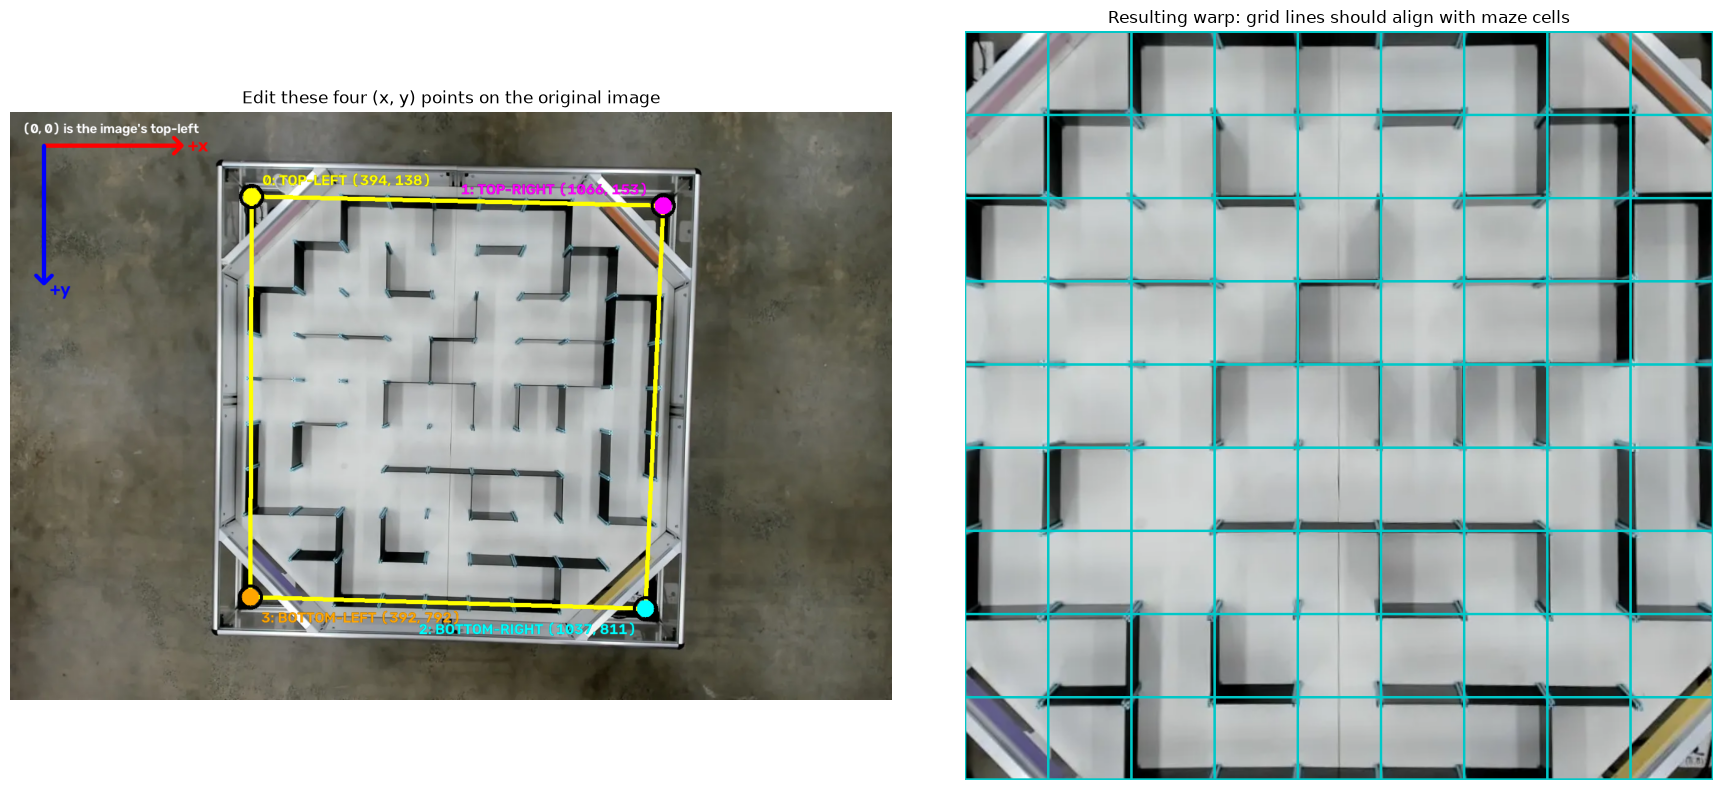

Start: (0, 2, 'E')
Goal: (4, 7)
Cell path: [(0, 2), (0, 3), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (5, 6), (5, 7), (4, 7)]
Command string: "frflffrfffflfflf"
Paste into Arduino: const char commandString[] = "frflffrfffflfflf";


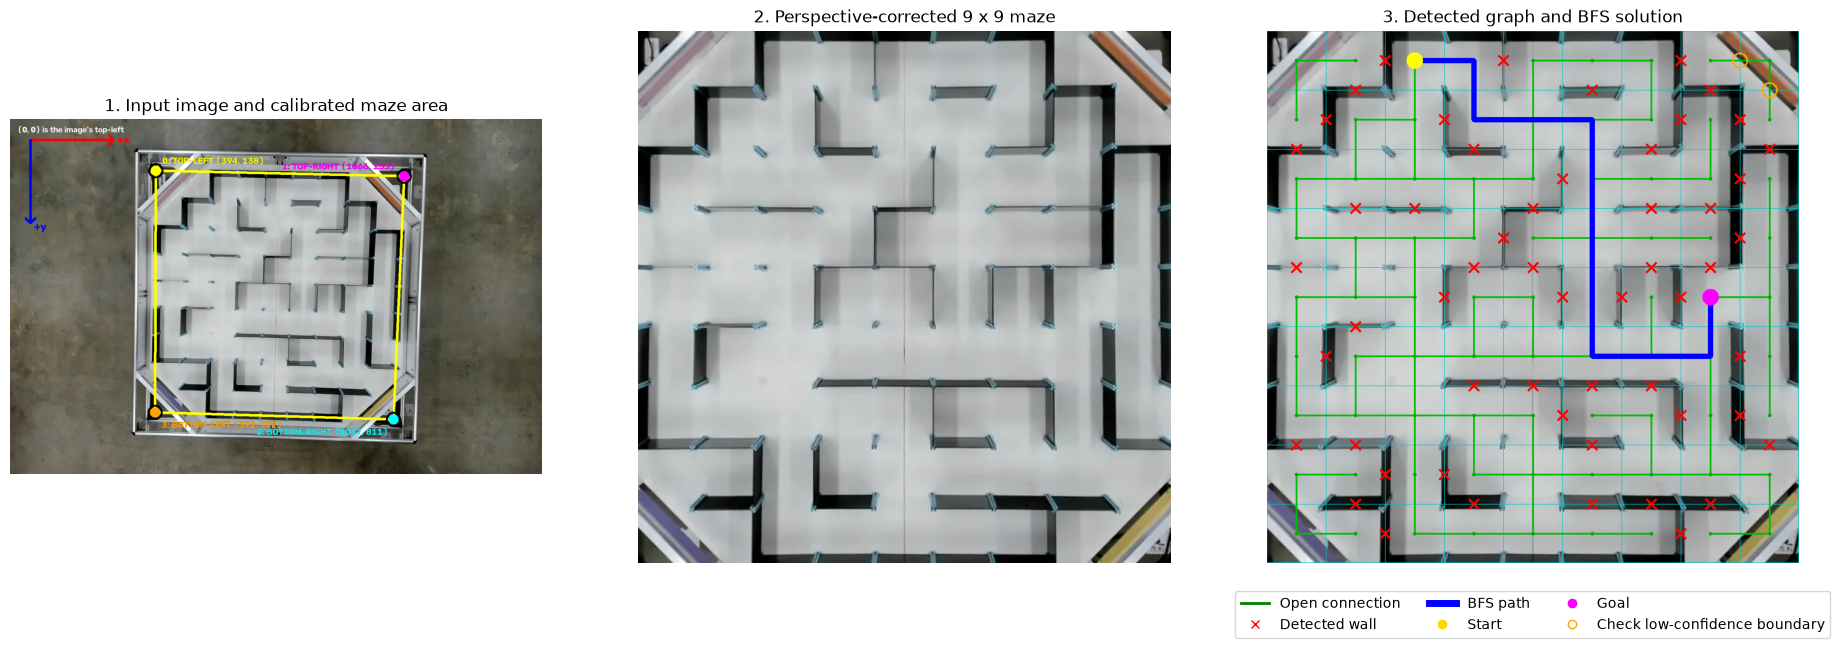

In [7]:
IMAGE_FILE = "maze.jpg"

# First check that the four maze corners and rectified grid align correctly.
show_maze_corner_calibration(IMAGE_FILE, MAZE_CORNERS)

# Replace these with the values provided by the demonstrator.
START = (0, 2, "E")
GOAL = (4, 7)

cell_path, command_string, result_image = solve_maze(
    IMAGE_FILE,
    START,
    GOAL,
    maze_corners=MAZE_CORNERS,
)
